# Joint TV V2 (Reparameterized)

Variant of `03 - Joint TV V2.ipynb` using `ObjectMultiplexReparameterized`
(mean/excitation parameterization) via
`method_wrappers.co_reconstruction_regularized_reparam`, instead of
`ObjectMultiplexed` + `method_wrappers.co_reconstruction_regularized`. Steps:

1. Plot the ground-truth base / excited / diff phase.
2. Run the joint (multiplexed) reconstruction with `tv_weight_excitation=0`.
3. Run it again with a reasonable `tv_weight_excitation`, at optimal (noiseless) dose.
4. Sweep `tv_weight_excitation` over a wide range to see where it actually starts
   to regularize the differential (excitation) signal.

The dose scan will be added later.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle

import numpy as np
from matplotlib import pyplot as plt

from quantem.core import config

import method_wrappers
from visualizers import plot_image_diffs

config.set_device(0)
print(config.get("device"))


cuda:0
cuda:0


## Load data

In [3]:
with open("./hbn_ptycho_datacubes_checkerboard.pkl", "rb") as f:
    data = pickle.load(f)

merged_scan = data["merged_scan"]
scan_mask = data["scan_mask"]

# scan_params follows method_wrappers' convention: 'scan_step' is the coarse
# (half-resolution, single de-interlaced channel) grid step -- the native
# merged_scan step is scan_step / 2.
SCAN_STEP_SIZE = 0.39285714285714285
scan_params = dict(
    probe_energy=data["acc_voltage"],
    probe_semiangle=data["conv_angle_mrad"],
    probe_defocus=data["defocus_A"],
    scan_step=SCAN_STEP_SIZE,
)
scan_params


{'probe_energy': 60000.0,
 'probe_semiangle': 20,
 'probe_defocus': 30,
 'scan_step': 0.39285714285714285}

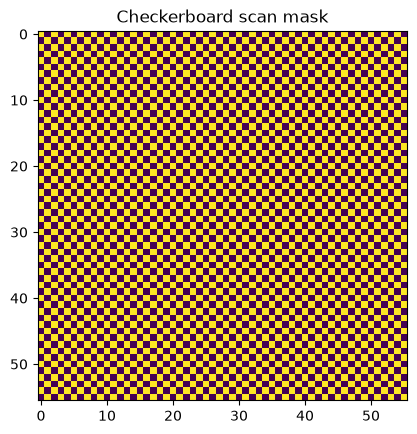

In [4]:
plt.imshow(scan_mask)
plt.title("Checkerboard scan mask")
plt.show()


## Ground truth

`hbn_ptycho_datacubes_checkerboard.pkl` was simulated from the base/excited
phase pair in `bcenters_base_excited_phases.pkl` (same acc. voltage, convergence
angle, defocus, and scan step -- see `bcenters new.ipynb`).

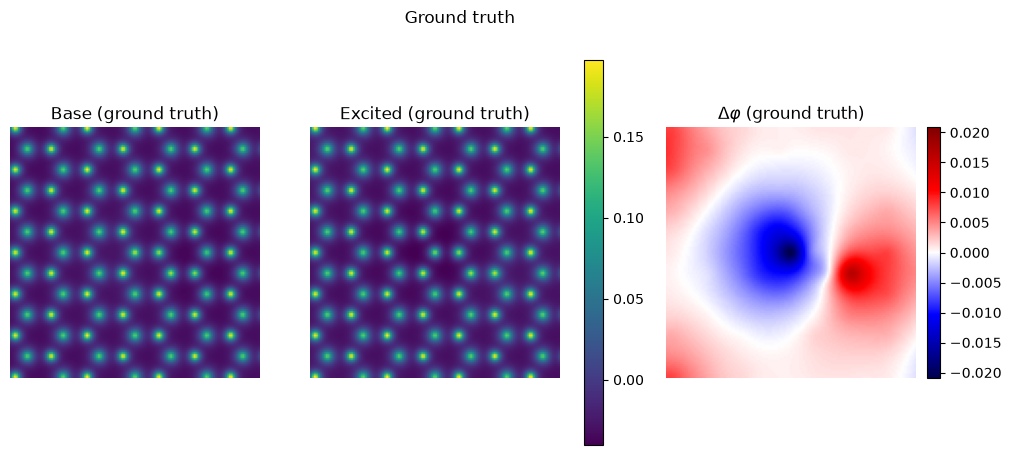

In [5]:
with open("./bcenters_base_excited_phases.pkl", "rb") as f:
    gt_data = pickle.load(f)

gt_base = gt_data["base"]
gt_excited = gt_data["excited"]

plot_image_diffs(
    gt_base,
    gt_excited,
    subtitles=["Base (ground truth)", "Excited (ground truth)", r"$\Delta\varphi$ (ground truth)"],
    suptitle="Ground truth",
)


## Joint reconstruction: `tv_weight_excitation = 0` (unregularized baseline)

Multiplexed (two-channel) co-reconstruction at native resolution, both the
mean-channel spatial TV (`tv_weight_mean`) and the excitation-channel TV
(`tv_weight_excitation`) disabled, at optimal (noiseless, already-normalized) dose.


In [6]:
result_tv0 = method_wrappers.co_reconstruction_regularized_reparam(
    merged_scan,
    scan_mask,
    scan_params,
    num_iters=100,
    tv_weight_mean=1.0,
    tv_weight_excitation=0.0,
    obj_lr=1e-3,
    probe_lr=1e-4,
    batch_size=128,
)


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/3136 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

/workspace/quantem_light_enhanced/quantem/src/quantem/diffractive_imaging/object_models.py:393: UserWarning: calculating TV loss for phase, need to check phase wrapping. Easiest fix is scalar phase array.
  warn(


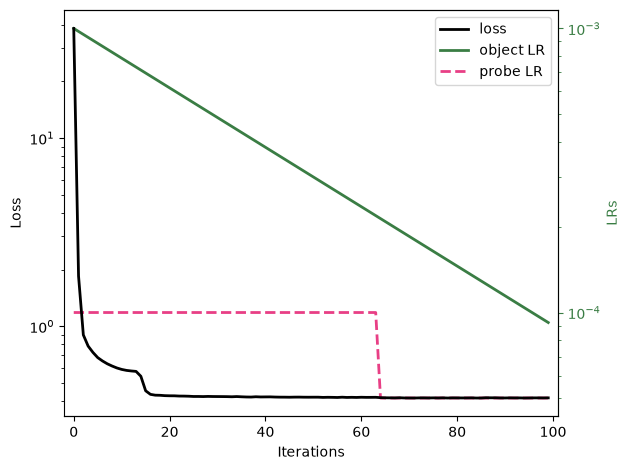

In [7]:
result_tv0["ptycho"].plot_losses()


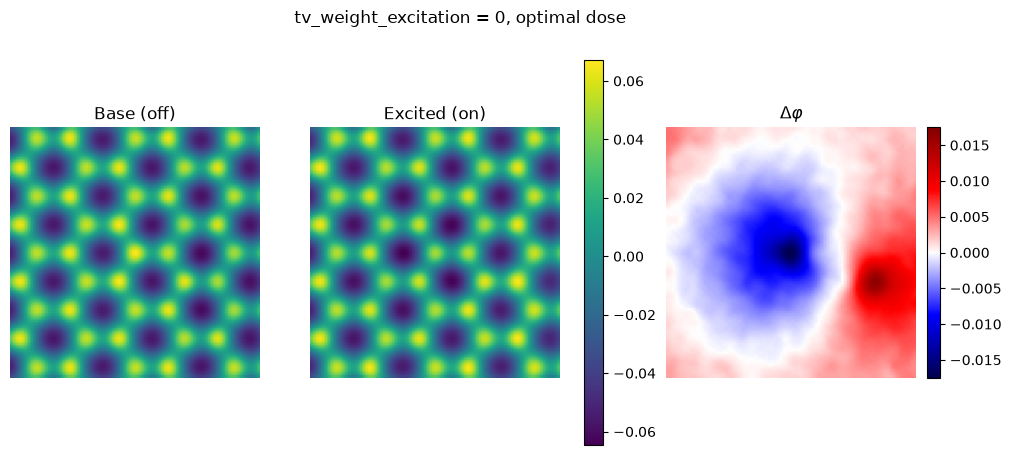

In [8]:
plot_image_diffs(
    result_tv0["phase_off"],
    result_tv0["phase_on"],
    subtitles=["Base (off)", "Excited (on)", r"$\Delta\varphi$"],
    suptitle="tv_weight_excitation = 0, optimal dose",
)


## Joint reconstruction: reasonable `tv_weight_excitation`, optimal dose

Same setup, with TV regularization on the excitation_obj channel directly --
which penalizes the spatial gradient magnitude of the (obj_excited - obj_base) / 2
channel, via `ObjectMultiplexReparameterized.apply_soft_constraints` -- turned
on to a reasonable strength. `tv_weight_mean` (the mean-channel spatial TV)
stays off so this isolates the effect of the excitation-channel regularizer.


In [13]:
result_tv = method_wrappers.co_reconstruction_regularized_reparam(
    merged_scan,
    scan_mask,
    scan_params,
    num_iters=100,
    tv_weight_mean=1.0,
    tv_weight_excitation=1.0,
    obj_lr=1e-3,
    probe_lr=1e-4,
    batch_size=128,
)


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/3136 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

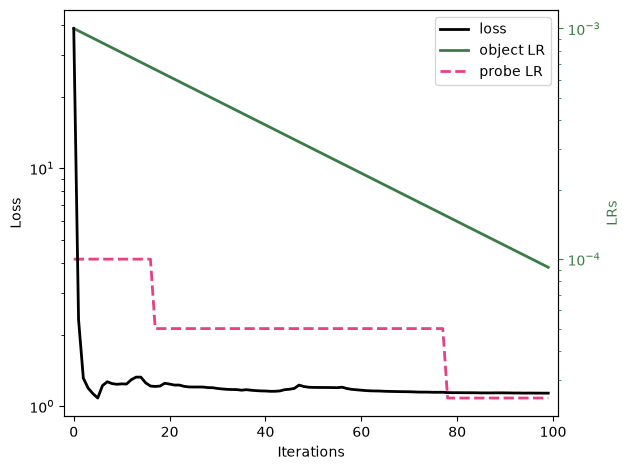

In [14]:
result_tv["ptycho"].plot_losses()

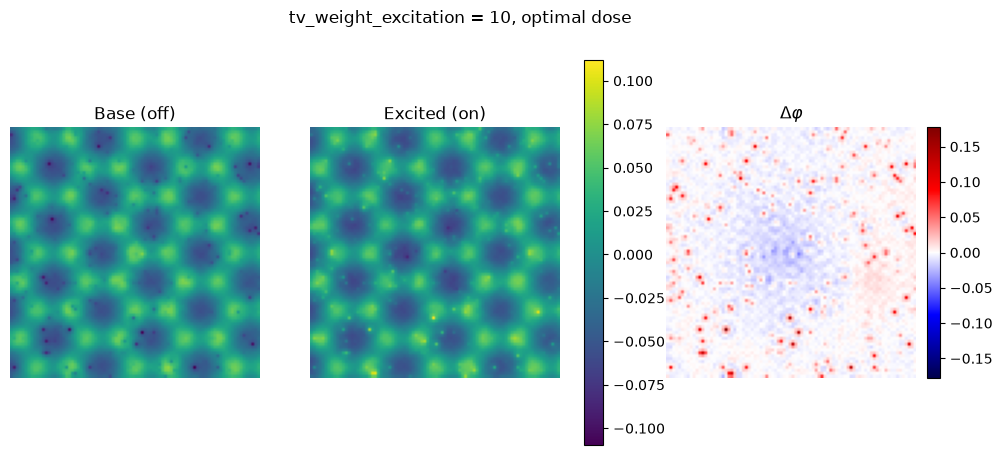

In [11]:
plot_image_diffs(
    result_tv["phase_off"],
    result_tv["phase_on"],
    subtitles=["Base (off)", "Excited (on)", r"$\Delta\varphi$"],
    suptitle="tv_weight_excitation = 10, optimal dose",
)


## Sweep `tv_weight_excitation`

`tv_weight_excitation=10` above looked indistinguishable from the unregularized
baseline, so sweep over a much wider range (`0` to `1e6`) to find where the
regularizer actually starts to bite. Reuses the two runs already done above
(`0` and `10`) and fills in the rest. `tv_weight_mean` stays `0` throughout so
the sweep isolates the excitation-channel regularizer's effect.


In [12]:
TV_WEIGHT_EXCITATION_SWEEP = [0.0, 10.0, 100.0, 1e3, 1e4, 1e5, 1e6]

sweep_results = {0.0: result_tv0, 10.0: result_tv}
for tv_weight_excitation in TV_WEIGHT_EXCITATION_SWEEP:
    if tv_weight_excitation in sweep_results:
        continue
    print(f"tv_weight_excitation = {tv_weight_excitation:g}")
    sweep_results[tv_weight_excitation] = method_wrappers.co_reconstruction_regularized_reparam(
        merged_scan,
        scan_mask,
        scan_params,
        num_iters=100,
        tv_weight_mean=0.0,
        tv_weight_excitation=tv_weight_excitation,
        obj_lr=1e-3,
        probe_lr=1e-4,
        batch_size=128,
    )


tv_weight_excitation = 100
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/3136 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

tv_weight_excitation = 1000
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/3136 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

tv_weight_excitation = 10000
Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/3136 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

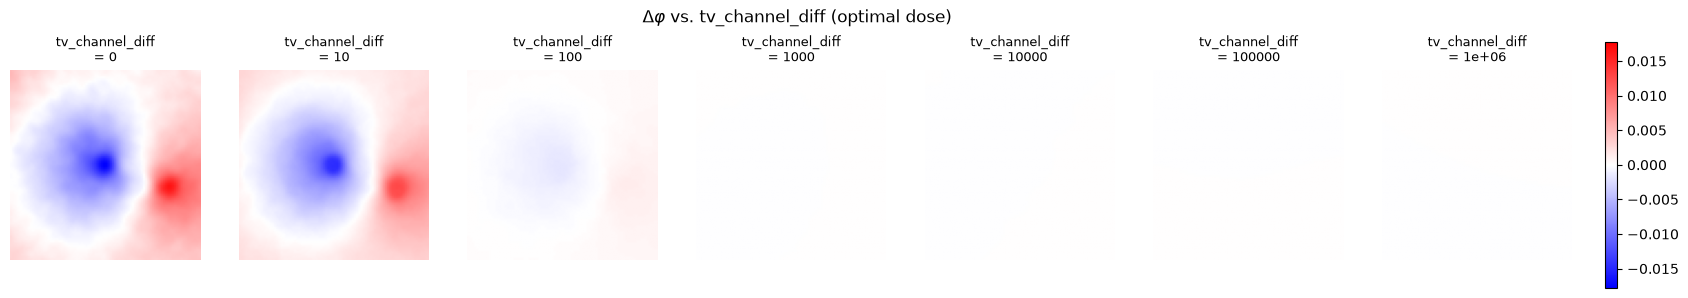

In [ ]:
sweep_values = sorted(sweep_results.keys())
vmax = max(np.abs(sweep_results[v]["delta_phi"]).max() for v in sweep_values)

fig, axes = plt.subplots(1, len(sweep_values), figsize=(3 * len(sweep_values), 3.2))
for ax, v in zip(axes, sweep_values):
    im = ax.imshow(sweep_results[v]["delta_phi"], cmap="bwr", vmin=-vmax, vmax=vmax)
    ax.set_title(f"tv_weight_excitation\n= {v:g}", fontsize=9)
    ax.set_axis_off()
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
fig.suptitle(r"$\Delta\varphi$ vs. tv_weight_excitation (optimal dose)")
plt.show()
